# Pedestrian Count Analysis - La Trobe Street vs Lonsdale Street

Author - Isaac McKissack

Source - https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour

In [1]:
# Importing Core Packages for use in Data Visualisation
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from scipy.signal import find_peaks
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# Importing Packages for Dataset Import
import urllib.request
import yaml
from pathlib import Path

# Load project configuration
config_path = Path("../config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

raw_dir = Path("../") / config["paths"]["raw_dir"]
raw_dir.mkdir(parents=True, exist_ok=True)

def download_url(url, dest_name):
    dest_path = raw_dir / dest_name
    if dest_path.exists():
        print(f"{dest_name} already exists. Skipping.")
        return
    print(f"Downloading {dest_name}...")
    urllib.request.urlretrieve(url, dest_path)
    print(f"Saved to {dest_path}")

# Download Dataset to local raw for processing

download_url(config["data_sources"]["pedestrian_counting_system"], "pedestrian_counting_system.geojson")



pedestrian_counting_system.geojson already exists. Skipping.


In [3]:
# Importing pedestrian data
pedestrian_data_raw = gpd.read_file("../data/raw/pedestrian_counting_system.geojson")

C:\Users\incar\Documents\University\Victoria-Urban-Planning\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 61320260807 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [4]:
# Data Head
pedestrian_data_raw.head(5)

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,geometry
0,19020260808,19,2026-08-08,0,213,311,524,LtB210_T,None,POINT (144.96551 -37.81237)
1,107020260808,107,2026-08-08,0,20,21,41,280Will_T,None,POINT (144.9569 -37.81246)
2,53120260808,53,2026-08-08,1,40,61,101,Col254_T,None,POINT (144.9655 -37.81564)
3,86120260808,86,2026-08-08,1,0,1,1,574Qub_T,None,POINT (144.94908 -37.8031)
4,58220260808,58,2026-08-08,2,24,61,85,Bou688_T,None,POINT (144.95358 -37.81686)


In [5]:
# Row Count
pedestrian_data_raw.shape
# 10 columns, 1,610,000+ observations

(1614785, 10)

In [6]:
# Scanning for nulls
pedestrian_data_raw.isna().sum()

# Null Locations due to quirk of dataset - not relevant

id                       0
location_id              0
sensing_date             0
hourday                  0
direction_1              0
direction_2              0
pedestriancount          0
sensor_name          25363
location           1614785
geometry             25363
dtype: int64

In [7]:
# Isolating for sensor_name with valid rows
pedestrian_data_clean = pedestrian_data_raw[pedestrian_data_raw['sensor_name'].notna()]
# Split dates
pedestrian_data_clean['year_month'] = pd.to_datetime(pedestrian_data_clean['sensing_date']).dt.strftime('%Y-%b')
pedestrian_data_clean['year'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).year
pedestrian_data_clean['month'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).month
pedestrian_data_clean['day'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).day
# Sort dates???
pedestrian_data_clean = pedestrian_data_clean.sort_values(by=['sensing_date'])
# How to sort the dates so they go properlllyyyyy

pedestrian_data_clean.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,geometry,year_month,year,month,day
1614784,852220240809,85,2024-08-09,22,17,11,28,488Mac_T,None,POINT (144.92973 -37.79432),2024-Aug,2024,8,9
1613470,72620240809,72,2024-08-09,6,45,24,69,ACMI_T,None,POINT (144.96873 -37.81726),2024-Aug,2024,8,9
1613471,492320240809,49,2024-08-09,23,117,138,255,Eli501_T,None,POINT (144.95956 -37.8073),2024-Aug,2024,8,9
1613472,84420240809,84,2024-08-09,4,25,36,61,ElFi_T,None,POINT (144.96503 -37.81798),2024-Aug,2024,8,9
1613473,1342320240809,134,2024-08-09,23,152,161,313,Spen201_T,None,POINT (144.95304 -37.81694),2024-Aug,2024,8,9


In [8]:
# Per a QGIS analysis of sensor locations, separate into two datasets - Lonsdale St and La Trobe St
# Lonsdale St - sensors 108, 47, 3 in broader buffer area
pedestrian_lonsdale = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin([133,108,56,52,47,3,30])]
pedestrian_lonsdale.name = "Lonsdale St"
pedestrian_lonsdale.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,geometry,year_month,year,month,day
1613479,521620240809,52,2024-08-09,16,456,319,775,Eli263_T,None,POINT (144.96194 -37.81252),2024-Aug,2024,8,9
1613494,56220240809,56,2024-08-09,2,8,13,21,Lon364_T,None,POINT (144.96153 -37.81235),2024-Aug,2024,8,9
1613467,561420240809,56,2024-08-09,14,307,308,615,Lon364_T,None,POINT (144.96153 -37.81235),2024-Aug,2024,8,9
1613461,56020240809,56,2024-08-09,0,19,39,58,Lon364_T,None,POINT (144.96153 -37.81235),2024-Aug,2024,8,9
1613499,1082320240809,108,2024-08-09,23,21,70,91,261Will_T,None,POINT (144.95679 -37.81296),2024-Aug,2024,8,9


In [9]:
# La Trobe St - sensors 108, 108, 59, 61, 66, 3 in broader buffer area
pedestrian_latrobe = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin([164,167,132,109,107,108,181,62,187,59,61,66,3])]
pedestrian_latrobe.name = "La Trobe St"
pedestrian_latrobe.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,geometry,year_month,year,month,day
1613444,622120240809,62,2024-08-09,21,308,272,580,Lat224_T,None,POINT (144.96217 -37.80996),2024-Aug,2024,8,9
1613447,62320240809,62,2024-08-09,3,21,20,41,Lat224_T,None,POINT (144.96217 -37.80996),2024-Aug,2024,8,9
1613452,61320240809,61,2024-08-09,3,16,7,23,RMIT14_T,None,POINT (144.96309 -37.80767),2024-Aug,2024,8,9
1613453,662220240809,66,2024-08-09,22,750,509,1259,QVN_T,None,POINT (144.96444 -37.81058),2024-Aug,2024,8,9
1613499,1082320240809,108,2024-08-09,23,21,70,91,261Will_T,None,POINT (144.95679 -37.81296),2024-Aug,2024,8,9


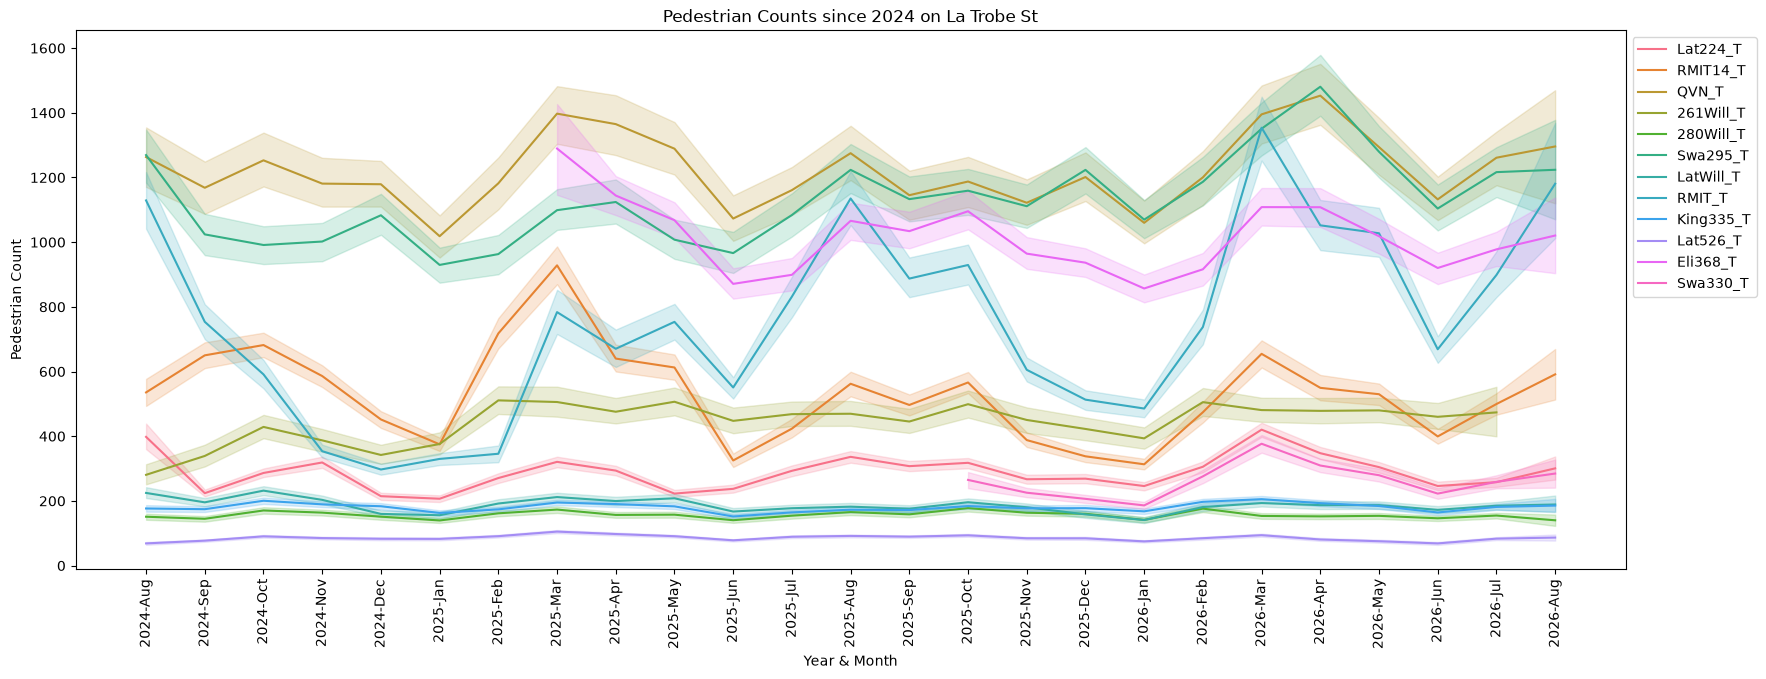

In [10]:
# Plot La Trobe St buffer sensors, allowing us to see any gaps that can explain overall trends

fig, ax = plt.subplots(figsize = (20, 7))
sns.lineplot(data = pedestrian_latrobe, x = "year_month", y = "pedestriancount", ax = ax, hue = "sensor_name")
plt.title("Pedestrian Counts since 2024 on La Trobe St")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend(bbox_to_anchor=(1, 1))

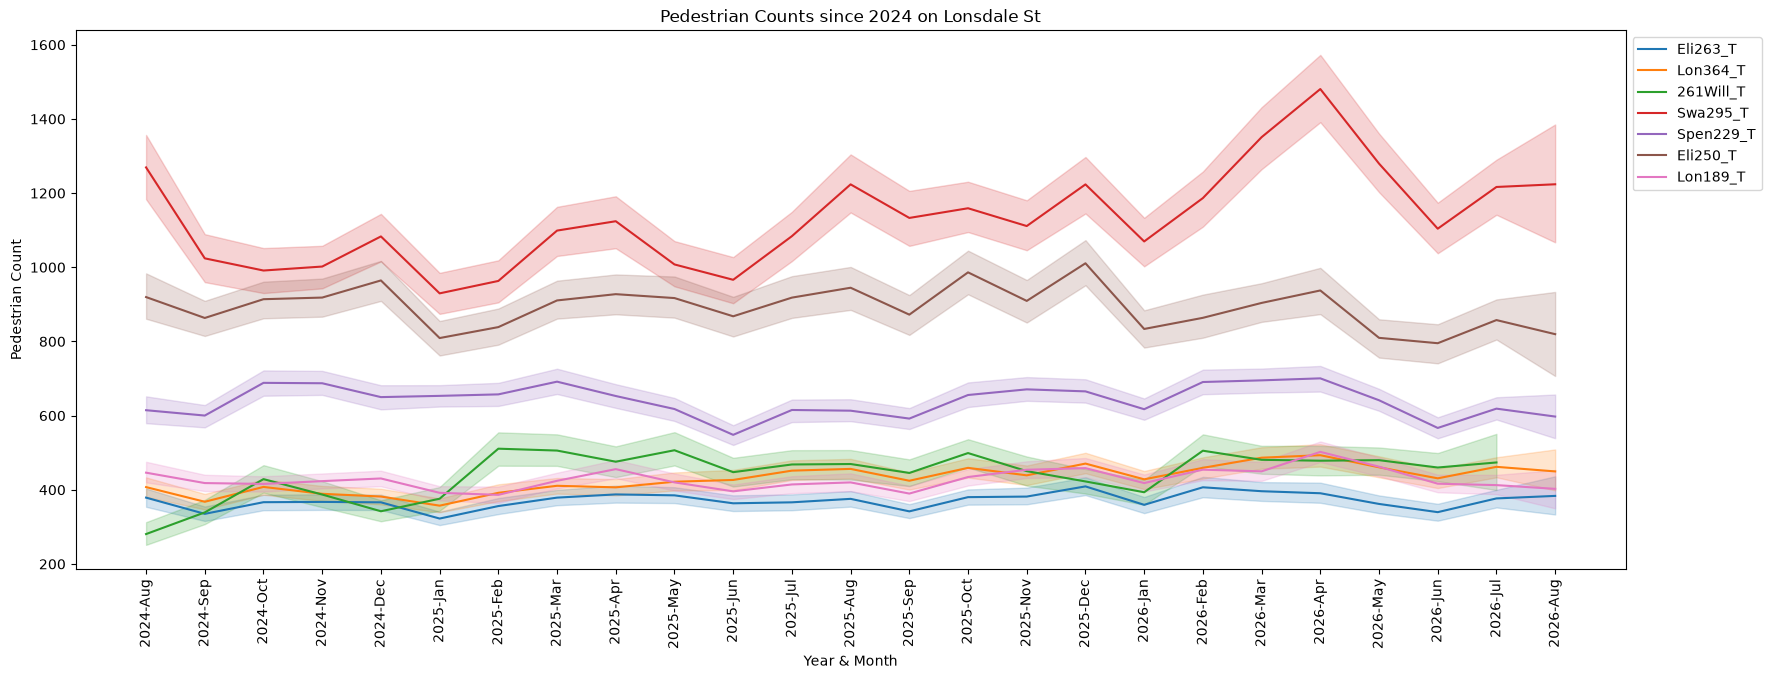

In [11]:
# Plot Lonsdale St buffer sensors, allowing us to see any gaps that can explain overall trends

fig, ax = plt.subplots(figsize = (20, 7))
sns.lineplot(data = pedestrian_lonsdale, x = "year_month", y = "pedestriancount", ax = ax, hue = "sensor_name")
plt.title("Pedestrian Counts since 2024 on Lonsdale St")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend(bbox_to_anchor=(1, 1))

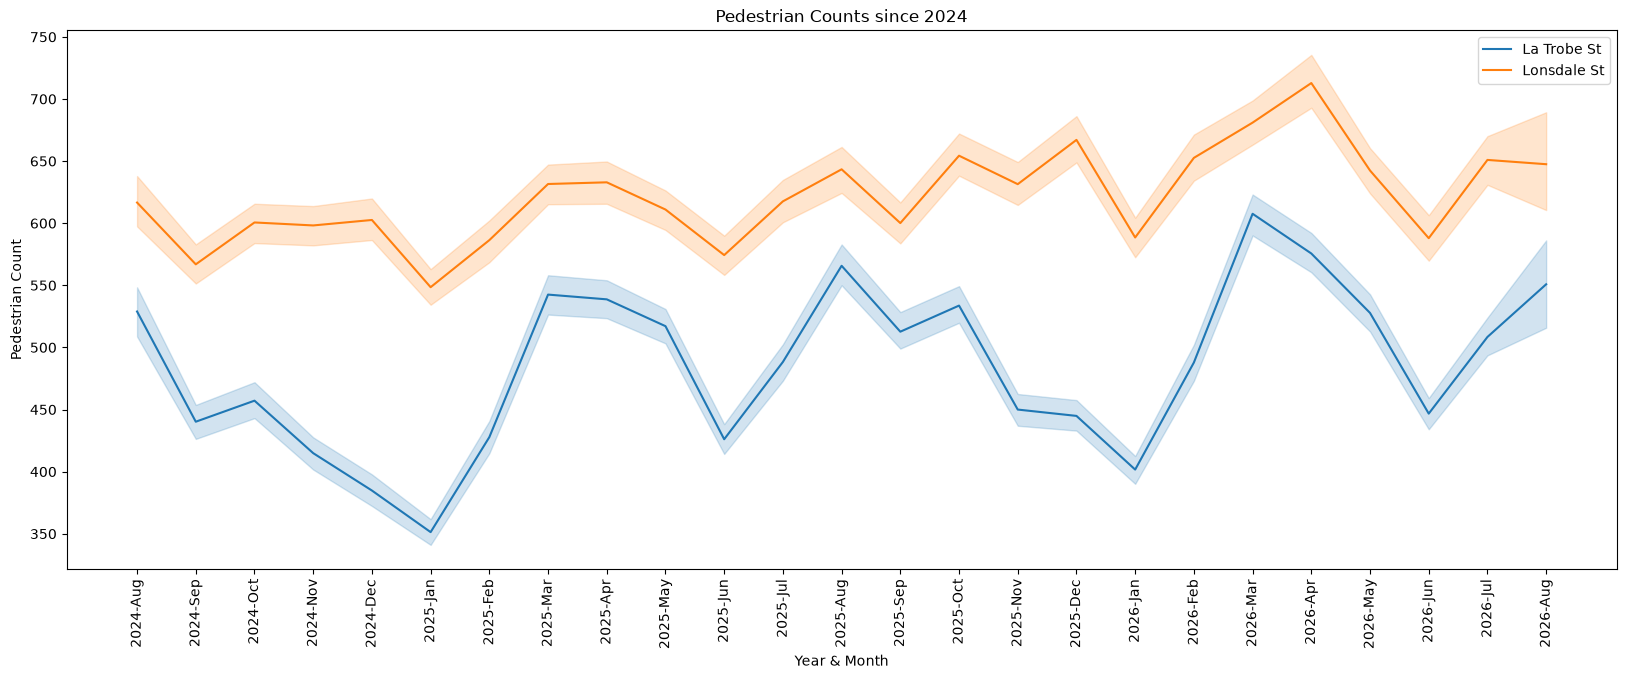

In [12]:
# Compare monthly pedestrian counts across La Trobe St and Lonsdale St

fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = pedestrian_latrobe, x = "year_month", y = "pedestriancount", ax = ax, label = "La Trobe St")
sns.lineplot(data = pedestrian_lonsdale, x = "year_month", y = "pedestriancount", ax = ax, label = "Lonsdale St")
plt.title("Pedestrian Counts since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend()

plt.show()